# Prototype 3 — Final Research Prototype

**Dataset:** NJ Transit + Amtrak (NEC) — Cross-year seasonal: 2018 (Oct–Dec) + 2019 (Jan–May)

**8 months covering autumn, winter, and spring — the peak disruption seasons.**

**Key additions over Prototype 2:**
- Cross-year data (2018–2019) for generalisation testing
- Seasonal analysis (autumn/winter/spring disruption patterns)
- Lagged features (7-day rolling disruption rate per segment)
- Hyperparameter tuning on the best model
- Segment-level early warning output with risk tiers

**Pipeline:** Load → Clean → Segment → Label → Features (inc. lagged) → Cross-Year Split → Train → Tune → Evaluate → Calibrate → Early Warning Output

In [1]:
# Installs and Imports
!pip install -q imbalanced-learn xgboost openpyxl

import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, time
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score, make_scorer
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from imblearn.over_sampling import SMOTE
from google.colab import drive
drive.mount('/content/drive')

EXPORT_DIR = 'prototype3_outputs'
os.makedirs(EXPORT_DIR, exist_ok=True)
print('All imports successful.')
print(f'Exports -> {EXPORT_DIR}/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports successful.
Exports -> prototype3_outputs/


## 1. Data Loading — Cross-Year Seasonal (2018 Oct–Dec + 2019 Jan–May)

In [2]:
# Load 8 months across two years

BASE_2018 = '/content/drive/MyDrive/Datasets/2018/'
BASE_2019 = '/content/drive/MyDrive/Datasets/2019/'

files = []
# 2018: Oct, Nov, Dec (autumn/winter)
for m in [10, 11, 12]:
    files.append((f'{BASE_2018}2018_{m:02d}.csv', f'2018_{m:02d}'))
# 2019: Jan, Feb, Mar, Apr, May (winter/spring)
for m in [1, 2, 3, 4, 5]:
    files.append((f'{BASE_2019}2019_{m:02d}.csv', f'2019_{m:02d}'))

missing = [f for f, _ in files if not os.path.exists(f)]
if missing:
    print('WARNING — Missing files:')
    for m in missing: print(f'  {m}')

dfs = []
for filepath, label in files:
    if not os.path.exists(filepath): continue
    temp = pd.read_csv(filepath)
    temp['source_file'] = label
    dfs.append(temp)
    print(f'Loaded {label}: {temp.shape[0]:,} rows')

df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Months loaded: {len(dfs)}')
print(df['source_file'].value_counts().sort_index())

Loaded 2018_10: 251,566 rows
Loaded 2018_11: 236,751 rows
Loaded 2018_12: 209,074 rows
Loaded 2019_01: 233,958 rows
Loaded 2019_02: 216,055 rows
Loaded 2019_03: 239,038 rows
Loaded 2019_04: 238,693 rows
Loaded 2019_05: 250,621 rows

Combined: 1,875,756 rows x 14 columns
Months loaded: 8
source_file
2018_10    251566
2018_11    236751
2018_12    209074
2019_01    233958
2019_02    216055
2019_03    239038
2019_04    238693
2019_05    250621
Name: count, dtype: int64


In [3]:
# Sanity checks

print('Columns:', df.columns.tolist())
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False))
print('\nFirst 5 rows:')
display(df.head())

Columns: ['date', 'train_id', 'stop_sequence', 'from', 'from_id', 'to', 'to_id', 'scheduled_time', 'actual_time', 'delay_minutes', 'status', 'line', 'type', 'source_file']

Missing values:
stop_sequence     197269
scheduled_time    197269
delay_minutes     197269
to_id                144
from_id              144
train_id               0
to                     0
from                   0
date                   0
actual_time            0
status                 0
line                   0
type                   0
source_file            0
dtype: int64

First 5 rows:


,date,train_id,stop_sequence,from,from_id,to,to_id,scheduled_time,actual_time,delay_minutes,status,line,type,source_file
0,2018-10-01,3701,1.0,New York Penn Station,105.0,New York Penn Station,105.0,2018-10-01 05:41:00,2018-10-01 05:40:04,0.000000,departed,Northeast Corrdr,NJ Transit,2018_10
1,2018-10-01,3701,2.0,New York Penn Station,105.0,Secaucus Upper Lvl,38187.0,2018-10-01 05:50:00,2018-10-01 05:51:23,1.383333,departed,Northeast Corrdr,NJ Transit,2018_10
2,2018-10-01,3701,3.0,Secaucus Upper Lvl,38187.0,Newark Penn Station,107.0,2018-10-01 05:58:00,2018-10-01 05:59:04,1.066667,departed,Northeast Corrdr,NJ Transit,2018_10
3,2018-10-01,3701,4.0,Newark Penn Station,107.0,Newark Airport,37953.0,2018-10-01 06:03:00,2018-10-01 06:04:10,1.166667,departed,Northeast Corrdr,NJ Transit,2018_10
4,2018-10-01,3701,5.0,Newark Airport,37953.0,Metropark,83.0,2018-10-01 06:17:00,2018-10-01 06:17:02,0.033333,departed,Northeast Corrdr,NJ Transit,2018_10


## 2. Data Cleaning

In [4]:
# Cleaning

df.columns = [c.strip() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['delay_minutes'] = pd.to_numeric(df['delay_minutes'], errors='coerce')
df['stop_sequence'] = pd.to_numeric(df['stop_sequence'], errors='coerce')
for col in ['scheduled_time', 'actual_time']:
    if col in df.columns: df[col] = pd.to_datetime(df[col], errors='coerce')

before = len(df)
df = df.dropna(subset=['date', 'delay_minutes']).copy()
df['year'] = df['date'].dt.year
print(f'Before: {before:,} | After: {len(df):,} | Dropped: {before-len(df):,} ({(before-len(df))/before*100:.1f}%)')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'\nRecords by year:')
print(df['year'].value_counts().sort_index())

Before: 1,875,756 | After: 1,678,487 | Dropped: 197,269 (10.5%)
Date range: 2018-10-01 to 2019-05-31

Records by year:
year
2018     625072
2019    1053415
Name: count, dtype: int64


count    1.678487e+06
mean     4.349182e+00
std      6.326687e+00
min      0.000000e+00
50%      3.000000e+00
75%      5.200000e+00
90%      9.300000e+00
95%      1.411667e+01
99%      3.036667e+01
max      3.260000e+02
Name: delay_minutes, dtype: float64


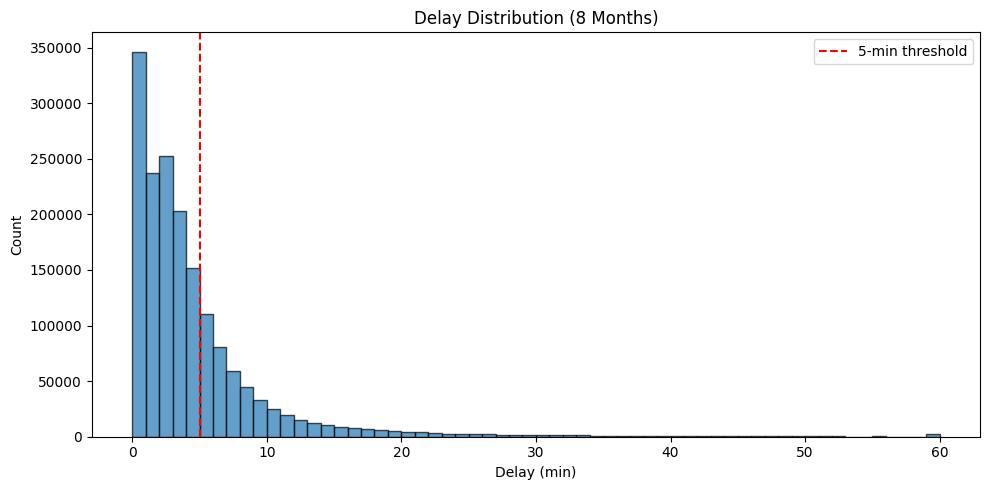

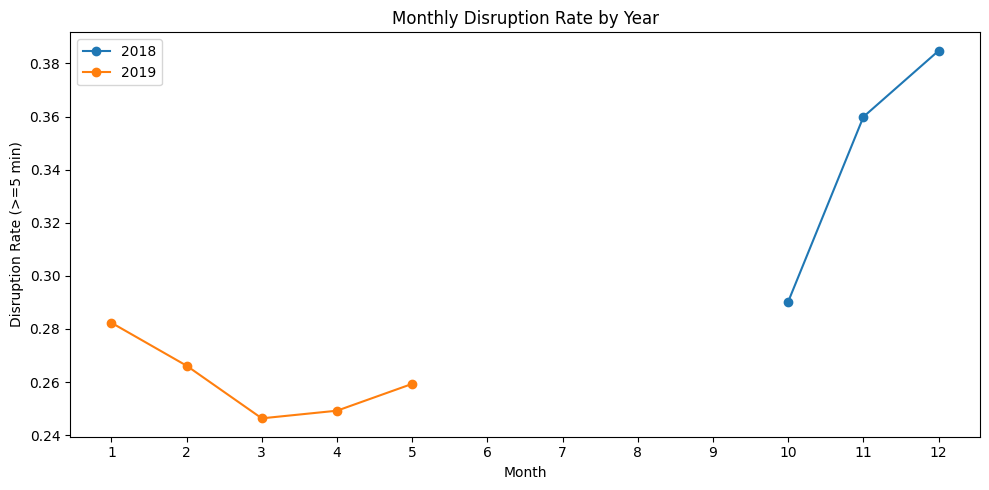

Saved: fig_delay_histogram.png + fig_monthly_disruption_by_year.png


In [5]:
# Delay distribution — individual plots

print(df['delay_minutes'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

# Plot 1: Delay histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['delay_minutes'].clip(upper=60), bins=60, edgecolor='black', alpha=0.7)
ax.axvline(x=5, color='red', linestyle='--', label='5-min threshold')
ax.set_xlabel('Delay (min)'); ax.set_ylabel('Count')
ax.set_title('Delay Distribution (8 Months)'); ax.legend()
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_delay_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Monthly disruption rate by year
fig, ax = plt.subplots(figsize=(10, 5))
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    monthly = subset.groupby(subset['date'].dt.month).apply(lambda g: (g['delay_minutes']>=5).mean())
    ax.plot(monthly.index, monthly.values, marker='o', label=str(year))
ax.set_xlabel('Month'); ax.set_ylabel('Disruption Rate (>=5 min)')
ax.set_title('Monthly Disruption Rate by Year'); ax.legend()
ax.set_xticks(range(1, 13))
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_monthly_disruption_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig_delay_histogram.png + fig_monthly_disruption_by_year.png')


## 3. Segment Construction, Labelling, and Seasonal Analysis

Unique segments: 572
Positive rate: 0.2909 (29.1%)
Imbalance ratio: 2.4:1

Disruption rate by year:
  2018: 0.3421 (34.2%)
  2019: 0.2605 (26.0%)


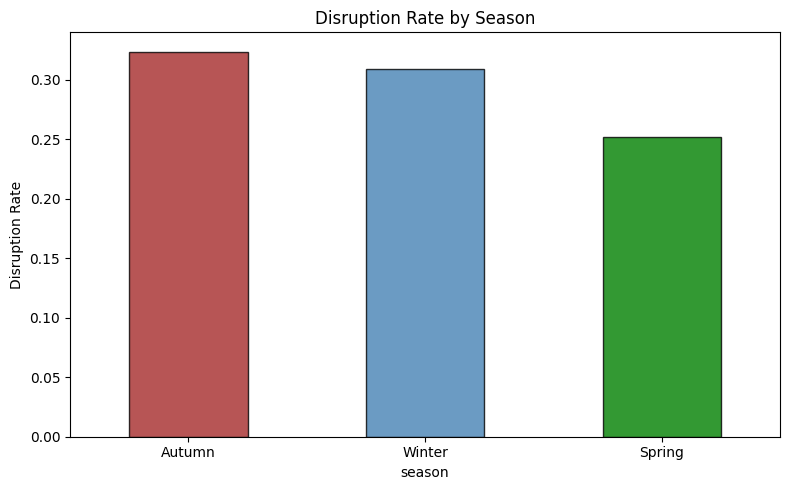

,class,count,label
0,0,1190256,No Disruption
1,1,488231,Disruption


,Season,Disruption_Rate,Record_Count
0,Autumn,0.323855,437557
1,Spring,0.251735,650812
2,Winter,0.309589,590118


Saved: label + seasonal tables + fig


In [6]:
# Segments, labels, seasonal analysis

if 'from_id' in df.columns and 'to_id' in df.columns:
    df['segment_id'] = df['from_id'].astype(str) + '->' + df['to_id'].astype(str)
else:
    df['segment_id'] = df['from'].astype(str) + '->' + df['to'].astype(str)

THRESHOLD_MIN = 5
df['disruption'] = (df['delay_minutes'] >= THRESHOLD_MIN).astype(int)

# Season mapping
season_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}
df['season'] = df['date'].dt.month.map(season_map)

print(f'Unique segments: {df["segment_id"].nunique()}')
print(f'Positive rate: {df["disruption"].mean():.4f} ({df["disruption"].mean()*100:.1f}%)')
print(f'Imbalance ratio: {(df["disruption"]==0).sum()/(df["disruption"]==1).sum():.1f}:1')

# Disruption rate by year
print(f'\nDisruption rate by year:')
for y, r in df.groupby('year')['disruption'].mean().items(): print(f'  {y}: {r:.4f} ({r*100:.1f}%)')

# Seasonal disruption rate
seasonal = df.groupby('season')['disruption'].mean()
available_seasons = [s for s in ['Autumn','Winter','Spring','Summer'] if s in seasonal.index]
seasonal = seasonal.reindex(available_seasons)

fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {'Spring':'green','Summer':'orange','Autumn':'brown','Winter':'steelblue'}
bar_colors = [colors_map.get(s, 'grey') for s in available_seasons]
seasonal.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Disruption Rate'); ax.set_title('Disruption Rate by Season')
ax.set_xticklabels(available_seasons, rotation=0)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_seasonal_disruption.png', dpi=150, bbox_inches='tight')
plt.show()

# Export label distribution
ld = df['disruption'].value_counts().reset_index()
ld.columns = ['class','count']; ld['label'] = ld['class'].map({0:'No Disruption',1:'Disruption'})
ld.to_excel(f'{EXPORT_DIR}/table_label_distribution.xlsx', index=False)
display(ld)

# Export seasonal table
seasonal_df = df.groupby('season')['disruption'].agg(['mean','count']).reset_index()
seasonal_df.columns = ['Season','Disruption_Rate','Record_Count']
seasonal_df.to_excel(f'{EXPORT_DIR}/table_seasonal_disruption.xlsx', index=False)
display(seasonal_df)
print(f'Saved: label + seasonal tables + fig')

## 4. Feature Engineering (Including Lagged Features)

In [7]:
# Base features

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['sched_hour'] = df['scheduled_time'].dt.hour if 'scheduled_time' in df.columns else 0
df['stop_sequence'] = df['stop_sequence'].fillna(0)
df['sched_hour'] = df['sched_hour'].fillna(0)
print('Base features created.')

Base features created.


In [8]:
# Lagged features — 7-day rolling disruption rate per segment

print('Computing lagged features...')
t0 = time.time()

df = df.sort_values(['segment_id', 'date']).copy()

# Aggregate to daily level per segment first (much faster than row-level rolling)
daily_seg = df.groupby(['segment_id', 'date']).agg(
    daily_disruption_rate=('disruption', 'mean'),
    daily_count=('disruption', 'count')
).reset_index().sort_values(['segment_id', 'date'])

# Rolling 7-day rate with shift(1) to prevent leakage
daily_seg['seg_rolling_7d_rate'] = daily_seg.groupby('segment_id')['daily_disruption_rate'].transform(
    lambda x: x.rolling(7, min_periods=1).mean().shift(1)
)
daily_seg['seg_rolling_7d_count'] = daily_seg.groupby('segment_id')['daily_count'].transform(
    lambda x: x.rolling(7, min_periods=1).sum().shift(1)
)

df = df.merge(daily_seg[['segment_id','date','seg_rolling_7d_rate','seg_rolling_7d_count']],
              on=['segment_id','date'], how='left')
df['seg_rolling_7d_rate'] = df['seg_rolling_7d_rate'].fillna(0)
df['seg_rolling_7d_count'] = df['seg_rolling_7d_count'].fillna(0)

print(f'Done in {time.time()-t0:.1f}s')
print(f'\nseg_rolling_7d_rate stats:')
print(df['seg_rolling_7d_rate'].describe())

Computing lagged features...
Done in 4.3s

seg_rolling_7d_rate stats:
count    1.678487e+06
mean     2.894170e-01
std      1.770704e-01
min      0.000000e+00
25%      1.567433e-01
50%      2.551948e-01
75%      4.018582e-01
max      1.000000e+00
Name: seg_rolling_7d_rate, dtype: float64


In [9]:
# Build feature matrix

feat_num = ['day_of_week','month','sched_hour','stop_sequence','is_weekend',
            'seg_rolling_7d_rate','seg_rolling_7d_count']
feat_cat = [c for c in ['line','type'] if c in df.columns]

X = pd.get_dummies(df[feat_num + feat_cat].copy(), columns=feat_cat, drop_first=True)
y = df['disruption'].copy()

print(f'Feature matrix: {X.shape}')
for i, col in enumerate(X.columns): print(f'  {i+1}. {col}')
display(X.head())

Feature matrix: (1678487, 17)
  1. day_of_week
  2. month
  3. sched_hour
  4. stop_sequence
  5. is_weekend
  6. seg_rolling_7d_rate
  7. seg_rolling_7d_count
  8. line_Bergen Co. Line 
  9. line_Gladstone Branch
  10. line_Main Line
  11. line_Montclair-Boonton
  12. line_Morristown Line
  13. line_No Jersey Coast
  14. line_Northeast Corrdr
  15. line_Pascack Valley
  16. line_Princeton Shuttle
  17. line_Raritan Valley


,day_of_week,month,sched_hour,stop_sequence,is_weekend,seg_rolling_7d_rate,seg_rolling_7d_count,line_Bergen Co. Line,line_Gladstone Branch,line_Main Line,line_Montclair-Boonton,line_Morristown Line,line_No Jersey Coast,line_Northeast Corrdr,line_Pascack Valley,line_Princeton Shuttle,line_Raritan Valley
0,6,5,19,1.0,1,0.0,0.0,False,False,False,False,False,False,False,False,False,False
1,6,5,19,1.0,1,0.0,0.0,False,False,False,False,False,False,False,False,False,False
2,6,5,12,1.0,1,0.0,0.0,False,False,False,False,False,False,False,False,False,False
3,6,5,8,1.0,1,0.0,0.0,False,False,False,False,False,False,False,False,False,False
4,6,5,21,1.0,1,0.0,0.0,False,False,False,False,False,False,False,False,False,False


## 5. Cross-Year Time-Based Split

In [10]:
# Cross-year split
# Train: 2018 Oct-Dec | Val: 2019 Jan-Feb | Test: 2019 Mar-May

df_sorted = df.sort_values('date').copy()
X_sorted = X.loc[df_sorted.index].copy()
y_sorted = y.loc[df_sorted.index].copy()

train_mask = df_sorted['date'] < '2019-01-01'
val_mask = (df_sorted['date'] >= '2019-01-01') & (df_sorted['date'] < '2019-03-01')
test_mask = df_sorted['date'] >= '2019-03-01'

X_train, y_train = X_sorted[train_mask], y_sorted[train_mask]
X_val, y_val = X_sorted[val_mask], y_sorted[val_mask]
X_test, y_test = X_sorted[test_mask], y_sorted[test_mask]

print('Cross-Year Split')
print(f'Train: 2018 Oct-Dec | {len(X_train):,} rows | pos: {y_train.mean():.4f}')
print(f'Val:   2019 Jan-Feb | {len(X_val):,} rows  | pos: {y_val.mean():.4f}')
print(f'Test:  2019 Mar-May | {len(X_test):,} rows  | pos: {y_test.mean():.4f}')
print(f'\nTrain on 2018 autumn/winter -> Test on 2019 winter/spring')

split_info = pd.DataFrame([
    {'Set':'Train','Period':'2018 Oct-Dec','Rows':len(X_train),'Pos_Rate':round(y_train.mean(),4)},
    {'Set':'Validation','Period':'2019 Jan-Feb','Rows':len(X_val),'Pos_Rate':round(y_val.mean(),4)},
    {'Set':'Test','Period':'2019 Mar-May','Rows':len(X_test),'Pos_Rate':round(y_test.mean(),4)},
])
display(split_info)
split_info.to_excel(f'{EXPORT_DIR}/table_split_info.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_split_info.xlsx')

Cross-Year Split
Train: 2018 Oct-Dec | 625,072 rows | pos: 0.3421
Val:   2019 Jan-Feb | 402,603 rows  | pos: 0.2746
Test:  2019 Mar-May | 650,812 rows  | pos: 0.2517

Train on 2018 autumn/winter -> Test on 2019 winter/spring


,Set,Period,Rows,Pos_Rate
0,Train,2018 Oct-Dec,625072,0.3421
1,Validation,2019 Jan-Feb,402603,0.2746
2,Test,2019 Mar-May,650812,0.2517


Saved: prototype3_outputs/table_split_info.xlsx


## 6. Model Training — Class Weighting

In [11]:
# Train all 3 models with class weighting

neg = (y_train==0).sum(); pos = (y_train==1).sum(); spw = neg/pos
print(f'Train — Neg: {neg:,}  Pos: {pos:,}  scale_pos_weight: {spw:.2f}')

def evaluate_model(model, X_e, y_e):
    yp = model.predict(X_e); ypr = model.predict_proba(X_e)[:,1]
    return {'y_pred':yp,'y_prob':ypr,'pr_auc':average_precision_score(y_e,ypr),
            'precision':precision_score(y_e,yp,zero_division=0),
            'recall':recall_score(y_e,yp,zero_division=0),
            'f1':f1_score(y_e,yp,zero_division=0),
            'accuracy':accuracy_score(y_e,yp),'cm':confusion_matrix(y_e,yp)}

models_w = {
    'LR + CW': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RF + CW': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB + CW': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, scale_pos_weight=spw,
                              eval_metric='aucpr', random_state=42, use_label_encoder=False)
}
results_w = {}
for name, mdl in models_w.items():
    print(f'\nTraining: {name}...')
    t0 = time.time()
    if 'XGB' in name: mdl.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else: mdl.fit(X_train, y_train)
    r = evaluate_model(mdl, X_test, y_test); r['model'] = mdl; results_w[name] = r
    print(f'  {time.time()-t0:.1f}s | PR-AUC:{r["pr_auc"]:.4f} | Prec:{r["precision"]:.4f} | Rec:{r["recall"]:.4f} | F1:{r["f1"]:.4f}')
    print(f'  CM:\n{r["cm"]}')
print('\nBaseline models done.')

Train — Neg: 411,211  Pos: 213,861  scale_pos_weight: 1.92

Training: LR + CW...
  182.8s | PR-AUC:0.4597 | Prec:0.4235 | Rec:0.5373 | F1:0.4737
  CM:
[[367159 119821]
 [ 75799  88033]]

Training: RF + CW...
  109.6s | PR-AUC:0.4840 | Prec:0.5112 | Rec:0.3945 | F1:0.4453
  CM:
[[425187  61793]
 [ 99204  64628]]

Training: XGB + CW...
  13.3s | PR-AUC:0.5134 | Prec:0.4729 | Rec:0.5516 | F1:0.5093
  CM:
[[386274 100706]
 [ 73464  90368]]

Baseline models done.


## 7. Model Training — Class Weighting + SMOTE

In [12]:
# SMOTE on training data only

print('Before SMOTE:', dict(pd.Series(y_train).value_counts()))
smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.75)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE: {dict(pd.Series(y_tr_sm).value_counts())}')
print(f'Size: {len(X_train):,} -> {len(X_tr_sm):,}')
print('Val/Test UNCHANGED.')

Before SMOTE: {0: np.int64(411211), 1: np.int64(213861)}
After SMOTE: {0: np.int64(411211), 1: np.int64(308408)}
Size: 625,072 -> 719,619
Val/Test UNCHANGED.


In [13]:
# Train SMOTE models

models_s = {
    'LR + CW + SMOTE': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'RF + CW + SMOTE': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB + CW + SMOTE': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, scale_pos_weight=spw,
                                       eval_metric='aucpr', random_state=42, use_label_encoder=False)
}
results_s = {}
for name, mdl in models_s.items():
    print(f'\nTraining: {name}...')
    if 'XGB' in name: mdl.fit(X_tr_sm, y_tr_sm, eval_set=[(X_val, y_val)], verbose=False)
    else: mdl.fit(X_tr_sm, y_tr_sm)
    r = evaluate_model(mdl, X_test, y_test); r['model'] = mdl; results_s[name] = r
    print(f'  PR-AUC:{r["pr_auc"]:.4f} | Prec:{r["precision"]:.4f} | Rec:{r["recall"]:.4f} | F1:{r["f1"]:.4f}')
    print(f'  CM:\n{r["cm"]}')
print('\nSMOTE models done.')


Training: LR + CW + SMOTE...
  PR-AUC:0.4572 | Prec:0.3947 | Rec:0.6013 | F1:0.4766
  CM:
[[335910 151070]
 [ 65326  98506]]

Training: RF + CW + SMOTE...
  PR-AUC:0.4855 | Prec:0.4714 | Rec:0.4984 | F1:0.4845
  CM:
[[395444  91536]
 [ 82185  81647]]

Training: XGB + CW + SMOTE...
  PR-AUC:0.5074 | Prec:0.4017 | Rec:0.7087 | F1:0.5128
  CM:
[[314050 172930]
 [ 47720 116112]]

SMOTE models done.


## 8. Hyperparameter Tuning

In [14]:
# Hyperparameter tuning — focused grid

print('Tuning XGBoost...')

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 150],
}

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
split_index = np.concatenate([np.full(len(X_train), -1), np.full(len(X_val), 0)])
ps = PredefinedSplit(split_index)

xgb_tuner = XGBClassifier(scale_pos_weight=spw, eval_metric='aucpr',
                           random_state=42, use_label_encoder=False, subsample=0.8)
pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

n_combos = len(param_grid['max_depth']) * len(param_grid['learning_rate']) * len(param_grid['n_estimators'])
print(f'{n_combos} parameter combinations...')
t0 = time.time()

grid_search = GridSearchCV(xgb_tuner, param_grid, cv=ps, scoring=pr_auc_scorer,
                           verbose=1, n_jobs=-1, refit=True)
grid_search.fit(X_trainval, y_trainval)

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'Best params: {grid_search.best_params_}')
print(f'Best val PR-AUC: {grid_search.best_score_:.4f}')

best_tuned = grid_search.best_estimator_
r_tuned = evaluate_model(best_tuned, X_test, y_test)
r_tuned['model'] = best_tuned
print(f'\nTuned XGB on TEST:')
print(f'  PR-AUC:{r_tuned["pr_auc"]:.4f} | Prec:{r_tuned["precision"]:.4f} | Rec:{r_tuned["recall"]:.4f} | F1:{r_tuned["f1"]:.4f}')

tuning_df = pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')[['params','mean_test_score','rank_test_score']].head(10)
display(tuning_df)
tuning_df.to_excel(f'{EXPORT_DIR}/table_hyperparameter_tuning.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_hyperparameter_tuning.xlsx')

Tuning XGBoost...
12 parameter combinations...
Fitting 1 folds for each of 12 candidates, totalling 12 fits

Done in 84.9s
Best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Best val PR-AUC: nan

Tuned XGB on TEST:
  PR-AUC:0.4872 | Prec:0.4785 | Rec:0.4620 | F1:0.4701


,params,mean_test_score,rank_test_score
0,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",NaN,1
1,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est...",NaN,1
2,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est...",NaN,1
3,"{'learning_rate': 0.05, 'max_depth': 6, 'n_est...",NaN,1
4,"{'learning_rate': 0.05, 'max_depth': 8, 'n_est...",NaN,1
5,"{'learning_rate': 0.05, 'max_depth': 8, 'n_est...",NaN,1
6,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",NaN,1
7,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",NaN,1
8,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",NaN,1
9,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",NaN,1


Saved: prototype3_outputs/table_hyperparameter_tuning.xlsx


## 9. Final Model Comparison

In [15]:
# Final comparison including tuned

all_r = {**results_w, **results_s, 'XGB + CW (Tuned)': r_tuned}

rows = [{'Model':n,'PR-AUC':round(r['pr_auc'],4),'Precision':round(r['precision'],4),
         'Recall':round(r['recall'],4),'F1':round(r['f1'],4),'Accuracy':round(r['accuracy'],4)}
        for n,r in all_r.items()]
final_comp = pd.DataFrame(rows).sort_values('PR-AUC', ascending=False).reset_index(drop=True)


print('PROTOTYPE 3 — FINAL MODEL COMPARISON (Cross-Year Test, >= 5 min)')

display(final_comp)
final_comp.to_excel(f'{EXPORT_DIR}/table_model_comparison_final.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_model_comparison_final.xlsx')

PROTOTYPE 3 — FINAL MODEL COMPARISON (Cross-Year Test, >= 5 min)


,Model,PR-AUC,Precision,Recall,F1,Accuracy
0,XGB + CW,0.5134,0.4729,0.5516,0.5093,0.7324
1,XGB + CW + SMOTE,0.5074,0.4017,0.7087,0.5128,0.6610
2,XGB + CW (Tuned),0.4872,0.4785,0.4620,0.4701,0.7378
3,RF + CW + SMOTE,0.4855,0.4714,0.4984,0.4845,0.7331
4,RF + CW,0.4840,0.5112,0.3945,0.4453,0.7526
5,LR + CW,0.4597,0.4235,0.5373,0.4737,0.6994
6,LR + CW + SMOTE,0.4572,0.3947,0.6013,0.4766,0.6675


Saved: prototype3_outputs/table_model_comparison_final.xlsx


## 10. Disruption Threshold Sensitivity — 5 min vs 10 min

In [16]:
# Threshold sensitivity — relabel at 10 minutes

# Compare performance when disruption is defined as >= 10 min
# vs the primary >= 5 min threshold. Uses the same features,
# same cross-year split, same model configuration.

THRESHOLD_10 = 10

# Create 10-min labels
df_sorted['disruption_10'] = (df_sorted['delay_minutes'] >= THRESHOLD_10).astype(int)

y_train_10 = df_sorted[train_mask]['disruption_10']
y_val_10 = df_sorted[val_mask]['disruption_10']
y_test_10 = df_sorted[test_mask]['disruption_10']

print(' Disruption Threshold Comparison')
print(f'\n5-minute threshold:')
print(f'  Train pos rate: {y_train.mean():.4f} ({y_train.mean()*100:.1f}%)')
print(f'  Test pos rate:  {y_test.mean():.4f} ({y_test.mean()*100:.1f}%)')
print(f'  Imbalance:      {(y_train==0).sum()/(y_train==1).sum():.1f}:1')

print(f'\n10-minute threshold:')
print(f'  Train pos rate: {y_train_10.mean():.4f} ({y_train_10.mean()*100:.1f}%)')
print(f'  Test pos rate:  {y_test_10.mean():.4f} ({y_test_10.mean()*100:.1f}%)')
print(f'  Imbalance:      {(y_train_10==0).sum()/(y_train_10==1).sum():.1f}:1')


 Disruption Threshold Comparison

5-minute threshold:
  Train pos rate: 0.3421 (34.2%)
  Test pos rate:  0.2517 (25.2%)
  Imbalance:      1.9:1

10-minute threshold:
  Train pos rate: 0.1233 (12.3%)
  Test pos rate:  0.0713 (7.1%)
  Imbalance:      7.1:1


In [17]:
# Train XGB + CW at 10-minute threshold

neg_10 = (y_train_10 == 0).sum()
pos_10 = (y_train_10 == 1).sum()
spw_10 = neg_10 / pos_10
print(f'10-min threshold — Neg: {neg_10:,}  Pos: {pos_10:,}  scale_pos_weight: {spw_10:.2f}')

xgb_10 = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=6,
    scale_pos_weight=spw_10, eval_metric='aucpr',
    random_state=42, use_label_encoder=False
)
xgb_10.fit(X_train, y_train_10, eval_set=[(X_val, y_val_10)], verbose=False)

r_10 = evaluate_model(xgb_10, X_test, y_test_10)
print(f'\nXGB + CW @ 10-min threshold (test set):')
print(f'  PR-AUC: {r_10["pr_auc"]:.4f} | Prec: {r_10["precision"]:.4f} | Rec: {r_10["recall"]:.4f} | F1: {r_10["f1"]:.4f}')
print(f'  CM:\n{r_10["cm"]}')

print(f'\nClassification Report @ 10-min:')
print(classification_report(y_test_10, r_10['y_pred'],
      target_names=['No Disruption','Disruption'], digits=4))


10-min threshold — Neg: 548,015  Pos: 77,057  scale_pos_weight: 7.11

XGB + CW @ 10-min threshold (test set):
  PR-AUC: 0.1866 | Prec: 0.1590 | Rec: 0.5573 | F1: 0.2474
  CM:
[[467621 136781]
 [ 20545  25865]]

Classification Report @ 10-min:
               precision    recall  f1-score   support

No Disruption     0.9579    0.7737    0.8560    604402
   Disruption     0.1590    0.5573    0.2474     46410

     accuracy                         0.7583    650812
    macro avg     0.5585    0.6655    0.5517    650812
 weighted avg     0.9009    0.7583    0.8126    650812



THRESHOLD COMPARISON — XGB + Class Weight (Cross-Year Test)


,Threshold,Pos_Rate_Train,Pos_Rate_Test,Imbalance,PR-AUC,Precision,Recall,F1
0,>= 5 min,34.2%,25.2%,1.9:1,0.5134,0.4729,0.5516,0.5093
1,>= 10 min,12.3%,7.1%,7.1:1,0.1866,0.1590,0.5573,0.2474


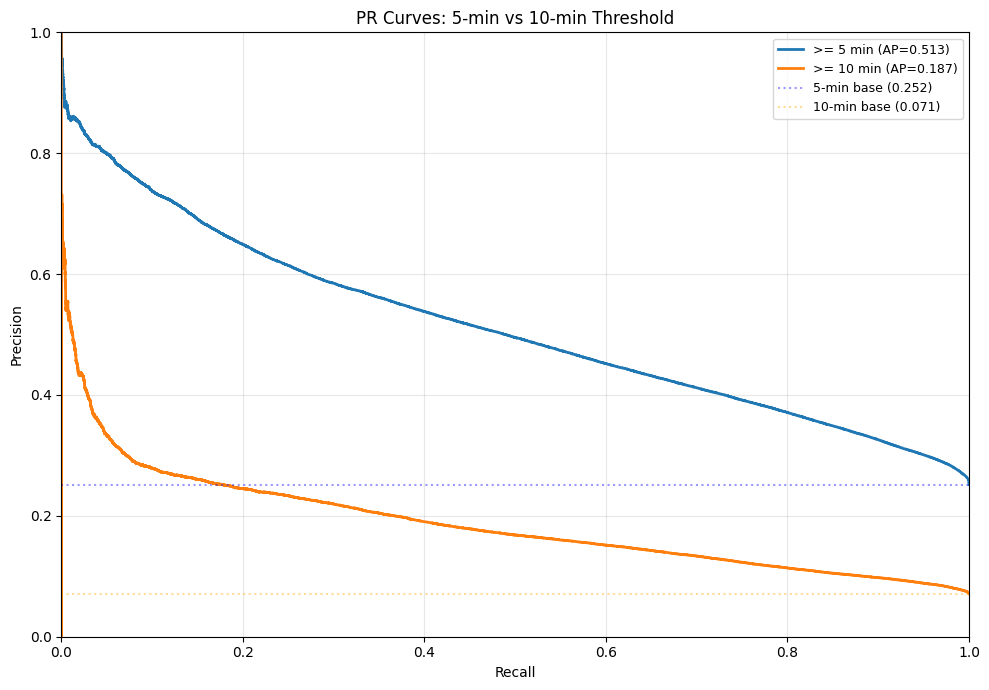

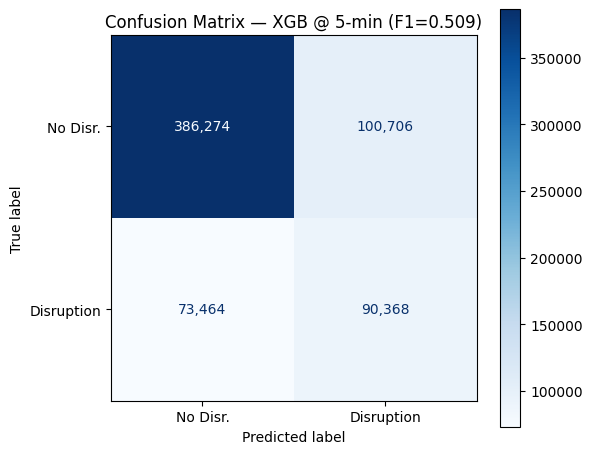

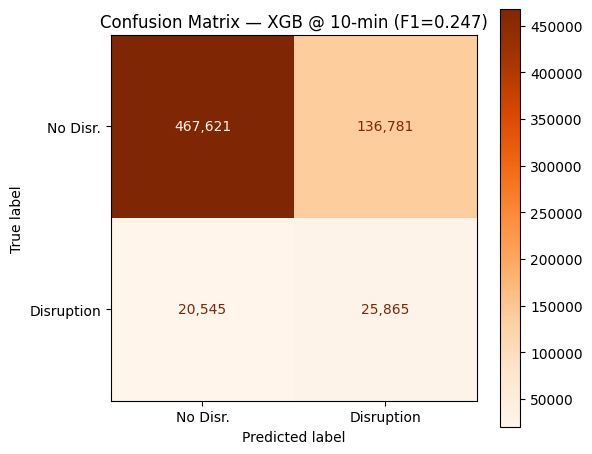

Saved: table + 3 individual figs


In [18]:
# Threshold comparison table + individual plots

r_5 = results_w['XGB + CW']

threshold_comp = pd.DataFrame([
    {'Threshold': '>= 5 min',
     'Pos_Rate_Train': f'{y_train.mean()*100:.1f}%',
     'Pos_Rate_Test': f'{y_test.mean()*100:.1f}%',
     'Imbalance': f'{(y_train==0).sum()/(y_train==1).sum():.1f}:1',
     'PR-AUC': round(r_5['pr_auc'], 4),
     'Precision': round(r_5['precision'], 4),
     'Recall': round(r_5['recall'], 4),
     'F1': round(r_5['f1'], 4)},
    {'Threshold': '>= 10 min',
     'Pos_Rate_Train': f'{y_train_10.mean()*100:.1f}%',
     'Pos_Rate_Test': f'{y_test_10.mean()*100:.1f}%',
     'Imbalance': f'{(y_train_10==0).sum()/(y_train_10==1).sum():.1f}:1',
     'PR-AUC': round(r_10['pr_auc'], 4),
     'Precision': round(r_10['precision'], 4),
     'Recall': round(r_10['recall'], 4),
     'F1': round(r_10['f1'], 4)},
])


print('THRESHOLD COMPARISON — XGB + Class Weight (Cross-Year Test)')

display(threshold_comp)
threshold_comp.to_excel(f'{EXPORT_DIR}/table_threshold_comparison_5v10.xlsx', index=False)

# Individual PR curve comparison
fig, ax = plt.subplots(figsize=(10, 7))
p5, rc5, _ = precision_recall_curve(y_test, r_5['y_prob'])
p10, rc10, _ = precision_recall_curve(y_test_10, r_10['y_prob'])
ax.plot(rc5, p5, label=f'>= 5 min (AP={r_5["pr_auc"]:.3f})', linewidth=2)
ax.plot(rc10, p10, label=f'>= 10 min (AP={r_10["pr_auc"]:.3f})', linewidth=2)
ax.axhline(y_test.mean(), ls=':', color='blue', alpha=0.4, label=f'5-min base ({y_test.mean():.3f})')
ax.axhline(y_test_10.mean(), ls=':', color='orange', alpha=0.4, label=f'10-min base ({y_test_10.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves: 5-min vs 10-min Threshold'); ax.legend(fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_pr_5v10.png', dpi=150, bbox_inches='tight')
plt.show()

# Individual CM for 5-min
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(r_5['cm'], display_labels=['No Disr.','Disruption']).plot(
    ax=ax, cmap='Blues', values_format=',')
ax.set_title(f'Confusion Matrix — XGB @ 5-min (F1={r_5["f1"]:.3f})')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_cm_5min.png', dpi=150, bbox_inches='tight')
plt.show()

# Individual CM for 10-min
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(r_10['cm'], display_labels=['No Disr.','Disruption']).plot(
    ax=ax, cmap='Oranges', values_format=',')
ax.set_title(f'Confusion Matrix — XGB @ 10-min (F1={r_10["f1"]:.3f})')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_cm_10min.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: table + 3 individual figs')


## 11. PR Curves

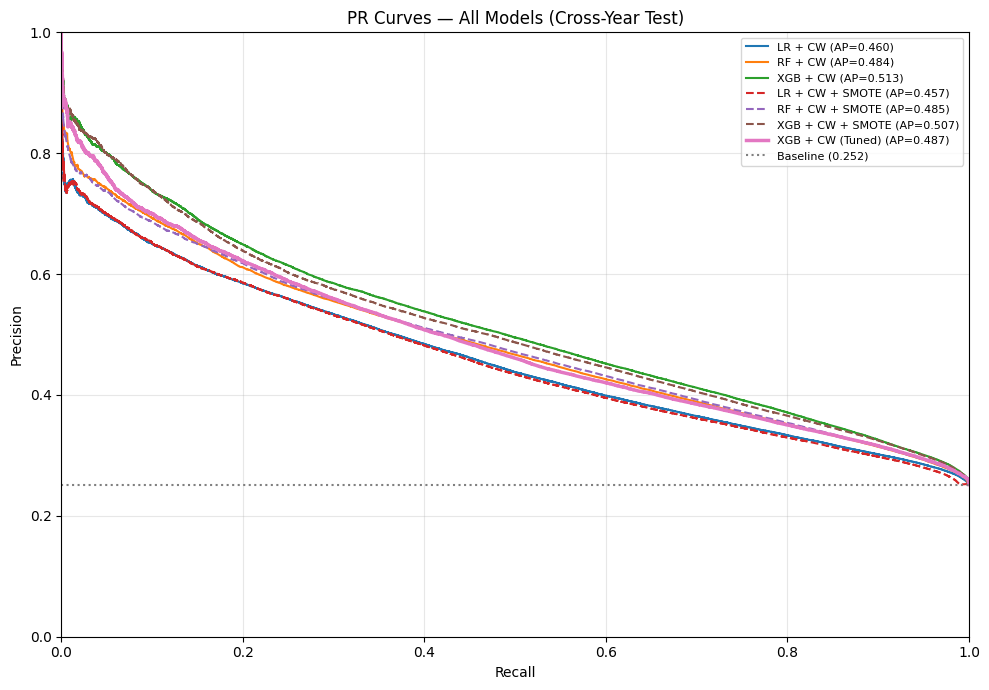

Saved: prototype3_outputs/fig_pr_curves.png


In [19]:
# PR curves

fig, ax = plt.subplots(figsize=(10, 7))
for name, r in all_r.items():
    p, rc, _ = precision_recall_curve(y_test, r['y_prob'])
    style = '--' if 'SMOTE' in name else '-'
    lw = 2.5 if 'Tuned' in name else 1.5
    ax.plot(rc, p, linestyle=style, linewidth=lw, label=f'{name} (AP={r["pr_auc"]:.3f})')
ax.axhline(y_test.mean(), ls=':', color='grey', label=f'Baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — All Models (Cross-Year Test)'); ax.legend(fontsize=8)
ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {EXPORT_DIR}/fig_pr_curves.png')

## 12. Confusion Matrices

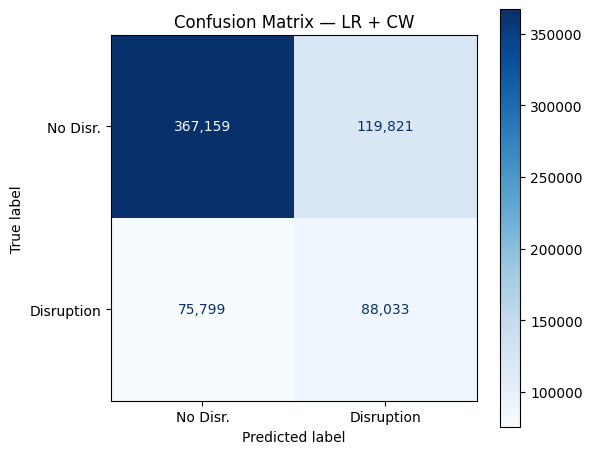

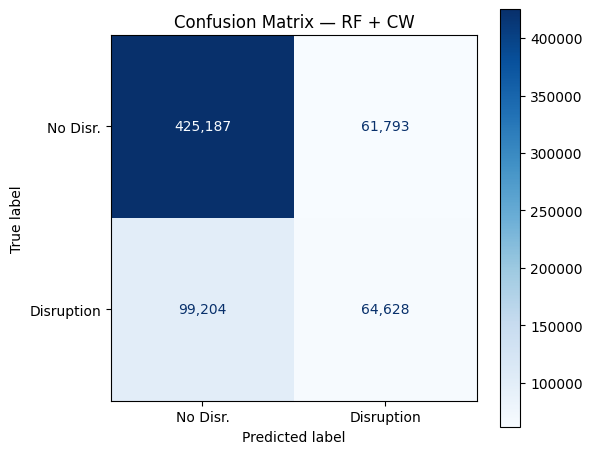

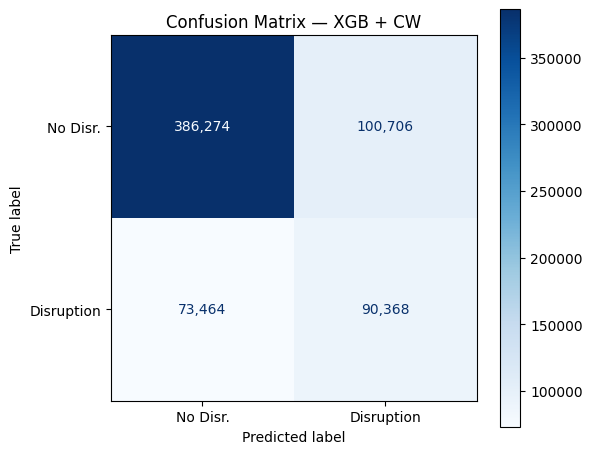

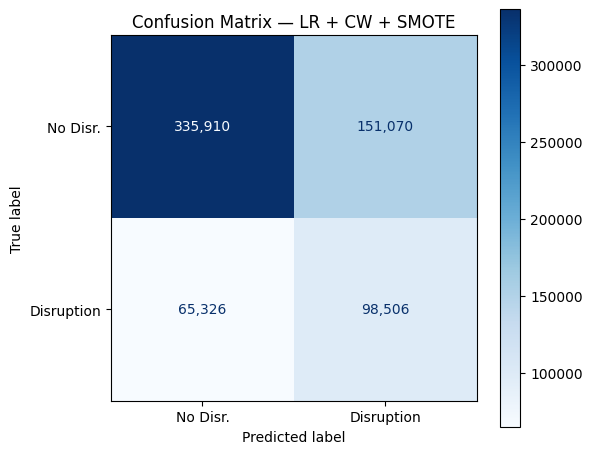

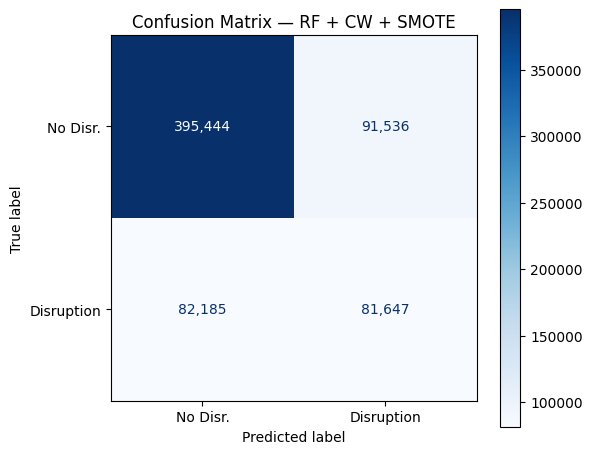

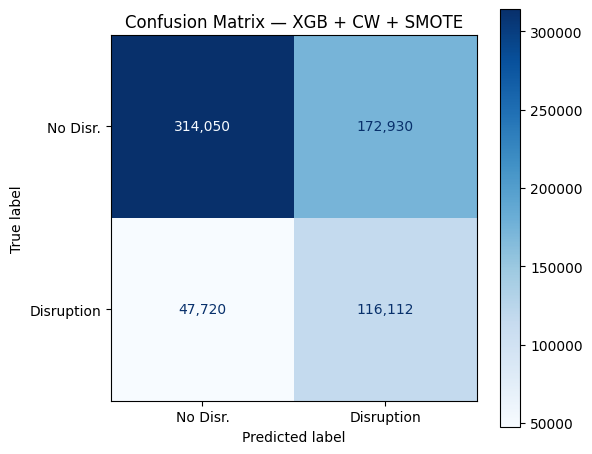

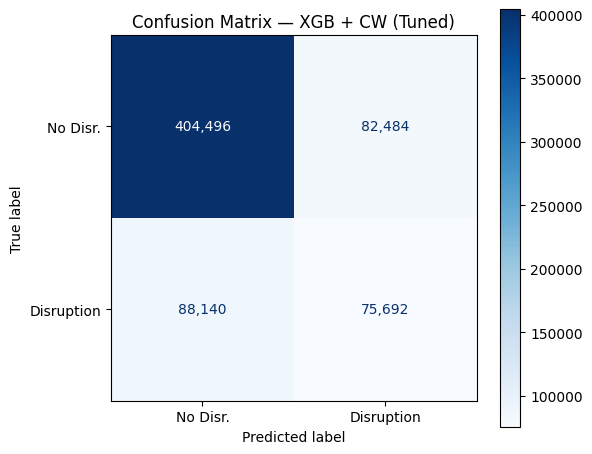

Saved: 7 individual confusion matrix figures


In [20]:
# Confusion matrices — individual plots

for name, r in all_r.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(r['cm'], display_labels=['No Disr.','Disruption']).plot(
        ax=ax, cmap='Blues', values_format=',')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    safe_name = name.replace(' ', '_').replace('+', '').replace('(', '').replace(')', '')
    fig.savefig(f'{EXPORT_DIR}/fig_cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
print(f'Saved: {len(all_r)} individual confusion matrix figures')


## 13. Threshold Analysis

Best threshold: 0.4 | Prec:0.4073 Rec:0.7257 F1:0.5217


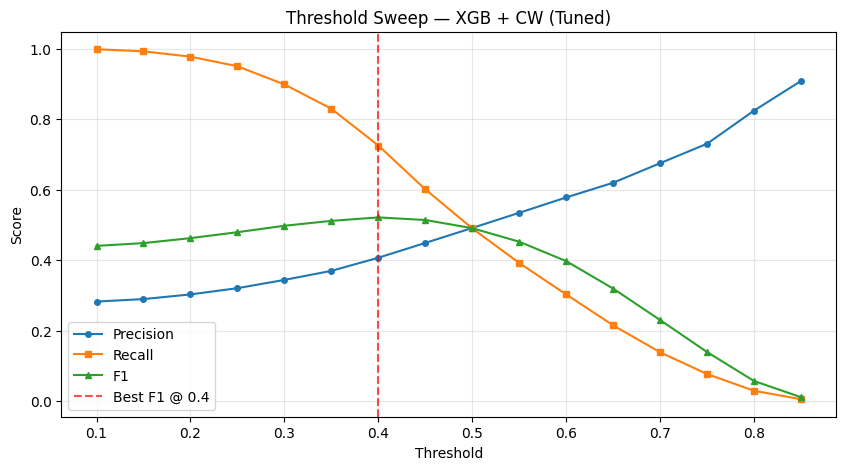

,threshold,precision,recall,f1
0,0.10,0.282955,0.999050,0.441006
1,0.15,0.289946,0.993034,0.448840
2,0.20,0.303236,0.977953,0.462931
3,0.25,0.320886,0.950786,0.479832
4,0.30,0.344415,0.899112,0.498047
5,0.35,0.370085,0.830267,0.511966
6,0.40,0.407268,0.725741,0.521745
7,0.45,0.449347,0.601540,0.514423
8,0.50,0.491788,0.490582,0.491185
9,0.55,0.534865,0.392480,0.452742


Saved: table + fig


In [21]:
# Threshold sweep (tuned model, validation set)

best_model = best_tuned; best_name = 'XGB + CW (Tuned)'
yv_prob = best_model.predict_proba(X_val)[:,1]
sweep = []
for t in np.arange(0.1, 0.9, 0.05):
    yv_p = (yv_prob >= t).astype(int)
    sweep.append({'threshold':round(t,2),'precision':precision_score(y_val,yv_p,zero_division=0),
                  'recall':recall_score(y_val,yv_p,zero_division=0),'f1':f1_score(y_val,yv_p,zero_division=0)})
sweep_df = pd.DataFrame(sweep)
best_row = sweep_df.loc[sweep_df['f1'].idxmax()]
best_thresh = best_row['threshold']
print(f'Best threshold: {best_thresh} | Prec:{best_row["precision"]:.4f} Rec:{best_row["recall"]:.4f} F1:{best_row["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(sweep_df['threshold'], sweep_df['precision'], label='Precision', marker='o', ms=4)
ax.plot(sweep_df['threshold'], sweep_df['recall'], label='Recall', marker='s', ms=4)
ax.plot(sweep_df['threshold'], sweep_df['f1'], label='F1', marker='^', ms=4)
ax.axvline(x=best_thresh, ls='--', color='red', alpha=0.7, label=f'Best F1 @ {best_thresh}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title(f'Threshold Sweep — {best_name}'); ax.legend(); ax.grid(True, alpha=0.3)
sweep_df.to_excel(f'{EXPORT_DIR}/table_threshold_sweep.xlsx', index=False)
fig.savefig(f'{EXPORT_DIR}/fig_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
display(sweep_df)
print(f'Saved: table + fig')

In [22]:
# Apply threshold to TEST set

yt_prob = best_model.predict_proba(X_test)[:,1]
yt_pred = (yt_prob >= best_thresh).astype(int)
print(f'FINAL Test Results (threshold={best_thresh}) ')
print(f'PR-AUC:  {average_precision_score(y_test,yt_prob):.4f}')
print(f'Prec:    {precision_score(y_test,yt_pred,zero_division=0):.4f}')
print(f'Recall:  {recall_score(y_test,yt_pred,zero_division=0):.4f}')
print(f'F1:      {f1_score(y_test,yt_pred,zero_division=0):.4f}')
print(classification_report(y_test, yt_pred, target_names=['No Disruption','Disruption'], digits=4))

final_results = pd.DataFrame([{'Model':best_name,'Threshold':best_thresh,
    'PR-AUC':round(average_precision_score(y_test,yt_prob),4),
    'Precision':round(precision_score(y_test,yt_pred,zero_division=0),4),
    'Recall':round(recall_score(y_test,yt_pred,zero_division=0),4),
    'F1':round(f1_score(y_test,yt_pred,zero_division=0),4)}])
display(final_results)
final_results.to_excel(f'{EXPORT_DIR}/table_final_test_results.xlsx', index=False)
print(f'Saved: {EXPORT_DIR}/table_final_test_results.xlsx')

FINAL Test Results (threshold=0.4) 
PR-AUC:  0.4872
Prec:    0.3876
Recall:  0.6913
F1:      0.4967
               precision    recall  f1-score   support

No Disruption     0.8590    0.6325    0.7286    486980
   Disruption     0.3876    0.6913    0.4967    163832

     accuracy                         0.6473    650812
    macro avg     0.6233    0.6619    0.6126    650812
 weighted avg     0.7403    0.6473    0.6702    650812



,Model,Threshold,PR-AUC,Precision,Recall,F1
0,XGB + CW (Tuned),0.4,0.4872,0.3876,0.6913,0.4967


Saved: prototype3_outputs/table_final_test_results.xlsx


## 14. Probability Calibration

,Method,PR-AUC
0,Uncalibrated,0.4872
1,Platt,0.4872
2,Isotonic,0.4824


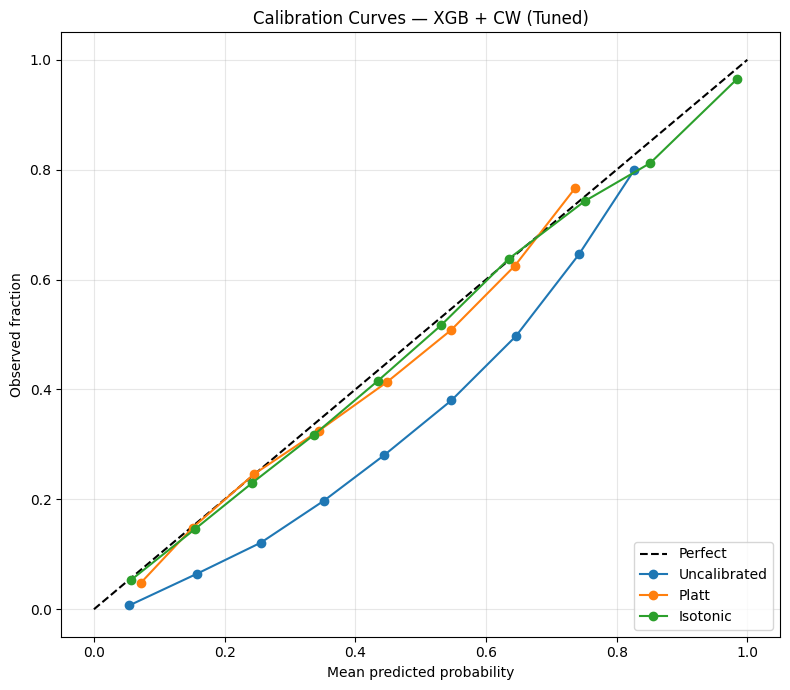

Saved: fig + table


In [23]:
# Calibration

cal_sig = CalibratedClassifierCV(best_model, method='sigmoid', cv='prefit'); cal_sig.fit(X_val, y_val)
cal_iso = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit'); cal_iso.fit(X_val, y_val)
p_uncal = best_model.predict_proba(X_test)[:,1]
p_sig = cal_sig.predict_proba(X_test)[:,1]
p_iso = cal_iso.predict_proba(X_test)[:,1]

cal_df = pd.DataFrame([
    {'Method':'Uncalibrated','PR-AUC':round(average_precision_score(y_test,p_uncal),4)},
    {'Method':'Platt','PR-AUC':round(average_precision_score(y_test,p_sig),4)},
    {'Method':'Isotonic','PR-AUC':round(average_precision_score(y_test,p_iso),4)}])
display(cal_df)
cal_df.to_excel(f'{EXPORT_DIR}/table_calibration_comparison.xlsx', index=False)

fig, ax = plt.subplots(figsize=(8,7))
ax.plot([0,1],[0,1],'k--', label='Perfect')
for lbl, p in [('Uncalibrated',p_uncal),('Platt',p_sig),('Isotonic',p_iso)]:
    pt, pp = calibration_curve(y_test, p, n_bins=10, strategy='uniform')
    ax.plot(pp, pt, marker='o', label=lbl)
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Observed fraction')
ax.set_title(f'Calibration Curves — {best_name}'); ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: fig + table')

## 15. Feature Importance

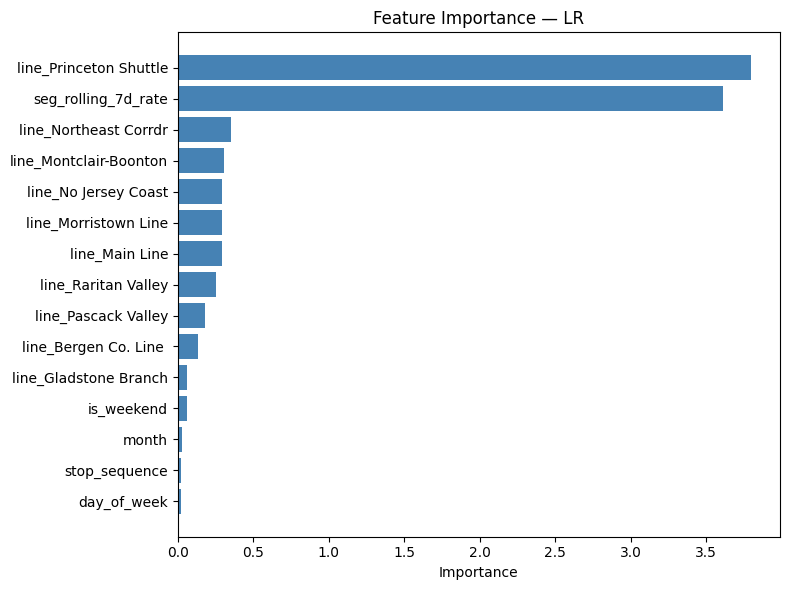

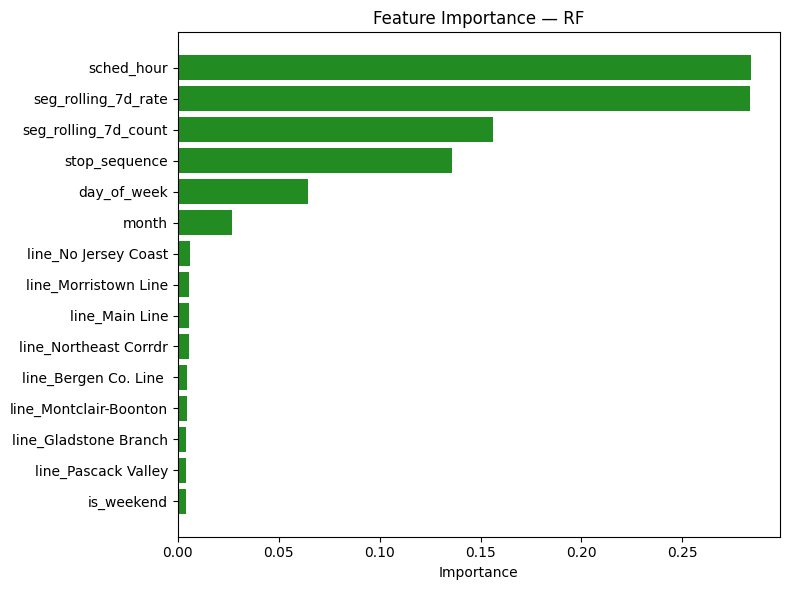

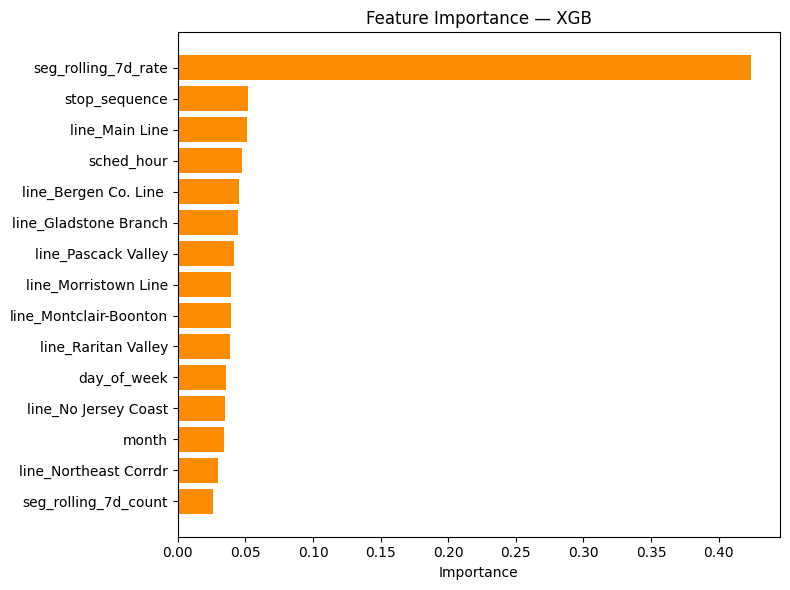

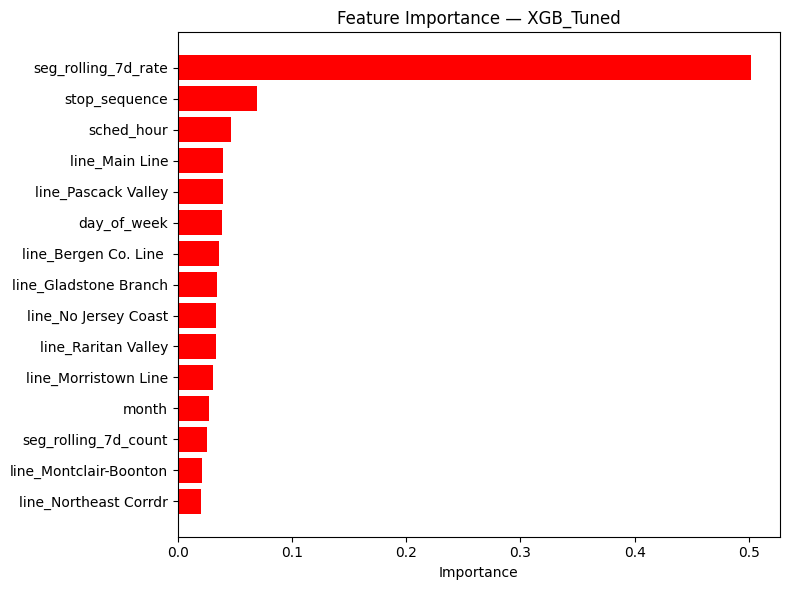


Top 10 — Tuned XGB:


,Feature,Importance
0,seg_rolling_7d_rate,0.502246
1,stop_sequence,0.068932
2,sched_hour,0.046261
3,line_Main Line,0.039732
4,line_Pascack Valley,0.039200
5,day_of_week,0.038636
6,line_Bergen Co. Line,0.036438
7,line_Gladstone Branch,0.034422
8,line_No Jersey Coast,0.033407
9,line_Raritan Valley,0.033097


Saved: 4 individual feature importance figs + 4 xlsx


In [24]:
# Feature importance — individual plots

fnames = X_train.columns.tolist()
imps = [('LR', np.abs(results_w['LR + CW']['model'].coef_[0]), 'steelblue'),
        ('RF', results_w['RF + CW']['model'].feature_importances_, 'forestgreen'),
        ('XGB', results_w['XGB + CW']['model'].feature_importances_, 'darkorange'),
        ('XGB_Tuned', best_tuned.feature_importances_, 'red')]

for label, imp, color in imps:
    fig, ax = plt.subplots(figsize=(8, 6))
    idx = np.argsort(imp)[::-1][:15]
    ax.barh([fnames[i] for i in idx], imp[idx], color=color)
    ax.set_xlabel('Importance'); ax.set_title(f'Feature Importance — {label}')
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(f'{EXPORT_DIR}/fig_feature_importance_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

for lbl, imp in [('lr',imps[0][1]),('rf',imps[1][1]),('xgb',imps[2][1]),('xgb_tuned',imps[3][1])]:
    pd.DataFrame({'Feature':fnames,'Importance':imp}).sort_values('Importance',ascending=False).to_excel(
        f'{EXPORT_DIR}/table_feature_importance_{lbl}.xlsx', index=False)

print('\nTop 10 — Tuned XGB:')
display(pd.DataFrame({'Feature':fnames,'Importance':best_tuned.feature_importances_}).sort_values('Importance',ascending=False).head(10).reset_index(drop=True))
print(f'Saved: 4 individual feature importance figs + 4 xlsx')


## 16. Segment-Level Early Warning Output

In [25]:
# Ranked segment risk

cal_model = cal_iso
test_df = df_sorted[test_mask].copy()
test_df['risk_score'] = cal_model.predict_proba(X_test)[:,1]

seg_risk = test_df.groupby('segment_id').agg(
    mean_risk=('risk_score','mean'), records=('risk_score','count'),
    actual_rate=('disruption','mean'), disruptions=('disruption','sum')
).reset_index()
seg_names = test_df.groupby('segment_id').agg(
    from_st=('from','first'), to_st=('to','first'), line=('line','first')
).reset_index()
seg_lagged = test_df.groupby('segment_id').agg(
    avg_7d_rate=('seg_rolling_7d_rate','mean')
).reset_index()

seg_risk = seg_risk.merge(seg_names, on='segment_id').merge(seg_lagged, on='segment_id', how='left')
seg_risk = seg_risk.sort_values('mean_risk', ascending=False).reset_index(drop=True)

In [26]:
# Early Warning System — risk tiers and alert output

def assign_risk_tier(risk_score):
    if risk_score >= 0.5: return 'HIGH'
    elif risk_score >= 0.35: return 'MEDIUM'
    elif risk_score >= 0.2: return 'LOW'
    else: return 'MINIMAL'

seg_risk['risk_tier'] = seg_risk['mean_risk'].apply(assign_risk_tier)
seg_risk['risk_pct'] = (seg_risk['mean_risk'] * 100).round(1)
seg_risk['explanation'] = seg_risk.apply(
    lambda row: f"Line: {row['line']} | Actual: {row['actual_rate']*100:.1f}% | "
                f"7d avg: {row.get('avg_7d_rate',0)*100:.1f}% | {row['records']} obs", axis=1)

wcols = ['segment_id','from_st','to_st','line','risk_tier','risk_pct',
         'actual_rate','avg_7d_rate','disruptions','records','explanation']


print('SEGMENT-LEVEL EARLY WARNING SYSTEM')
print('Model: Tuned XGBoost | Training: 2018 Oct-Dec | Test: 2019 Mar-May')


tier_summary = seg_risk['risk_tier'].value_counts().reindex(['HIGH','MEDIUM','LOW','MINIMAL']).fillna(0).astype(int)
print(f'\nRisk Tier Summary ({len(seg_risk)} segments):')
print(f'  HIGH:    {tier_summary.get("HIGH",0):>4} — immediate attention')
print(f'  MEDIUM:  {tier_summary.get("MEDIUM",0):>4} — monitor closely')
print(f'  LOW:     {tier_summary.get("LOW",0):>4} — routine monitoring')
print(f'  MINIMAL: {tier_summary.get("MINIMAL",0):>4} — no action needed')

for tier in ['HIGH','MEDIUM']:
    subset = seg_risk[seg_risk['risk_tier']==tier][wcols]

    print(f'{tier} RISK SEGMENTS ({len(subset)})')

    if len(subset) > 0: display(subset.head(20))
    else: print(f'No {tier} risk segments.')

seg_risk[wcols].to_excel(f'{EXPORT_DIR}/table_early_warning_output.xlsx', index=False)
tier_df = pd.DataFrame({'Risk_Tier':tier_summary.index,'Segment_Count':tier_summary.values})
tier_df.to_excel(f'{EXPORT_DIR}/table_risk_tier_summary.xlsx', index=False)
display(tier_df)
print(f'\nSaved: table_early_warning_output.xlsx + table_risk_tier_summary.xlsx')

SEGMENT-LEVEL EARLY WARNING SYSTEM
Model: Tuned XGBoost | Training: 2018 Oct-Dec | Test: 2019 Mar-May

Risk Tier Summary (541 segments):
  HIGH:      57 — immediate attention
  MEDIUM:    98 — monitor closely
  LOW:      179 — routine monitoring
  MINIMAL:  207 — no action needed
HIGH RISK SEGMENTS (57)


,segment_id,from_st,to_st,line,risk_tier,risk_pct,actual_rate,avg_7d_rate,disruptions,records,explanation
0,70.0->37953.0,Linden,Newark Airport,Northeast Corrdr,HIGH,86.3,1.000000,1.000000,1,1,Line: Northeast Corrdr | Actual: 100.0% | 7d a...
1,148.0->103.0,Trenton,New Brunswick,Northeast Corrdr,HIGH,85.0,0.984375,0.984375,63,64,Line: Northeast Corrdr | Actual: 98.4% | 7d av...
2,70.0->83.0,Linden,Metropark,Northeast Corrdr,HIGH,82.9,0.666667,0.896825,2,3,Line: Northeast Corrdr | Actual: 66.7% | 7d av...
3,70.0->103.0,Linden,New Brunswick,Northeast Corrdr,HIGH,82.9,1.000000,1.000000,1,1,Line: Northeast Corrdr | Actual: 100.0% | 7d a...
4,70.0->107.0,Linden,Newark Penn Station,No Jersey Coast,HIGH,82.9,1.000000,1.000000,1,1,Line: No Jersey Coast | Actual: 100.0% | 7d av...
5,37953.0->125.0,Newark Airport,Princeton Junction,Northeast Corrdr,HIGH,81.6,1.000000,0.857143,4,4,Line: Northeast Corrdr | Actual: 100.0% | 7d a...
6,127.0->83.0,Rahway,Metropark,Northeast Corrdr,HIGH,79.7,0.739979,0.775366,2123,2869,Line: Northeast Corrdr | Actual: 74.0% | 7d av...
7,62.0->118.0,Hillsdale,Pearl River,Pascack Valley,HIGH,72.8,1.000000,1.000000,1,1,Line: Pascack Valley | Actual: 100.0% | 7d avg...
8,132.0->62.0,River Edge,Hillsdale,Pascack Valley,HIGH,72.8,1.000000,1.000000,1,1,Line: Pascack Valley | Actual: 100.0% | 7d avg...
9,70.0->127.0,Linden,Rahway,No Jersey Coast,HIGH,72.4,0.704971,0.720389,3049,4325,Line: No Jersey Coast | Actual: 70.5% | 7d avg...


MEDIUM RISK SEGMENTS (98)


,segment_id,from_st,to_st,line,risk_tier,risk_pct,actual_rate,avg_7d_rate,disruptions,records,explanation
57,43298.0->1.0,Pennsauken,Philadelphia,Atl. City Line,MEDIUM,49.9,0.539604,0.504731,109,202,Line: Atl. City Line | Actual: 54.0% | 7d avg:...
58,130.0->73.0,Red Bank,Little Silver,No Jersey Coast,MEDIUM,49.8,0.487816,0.506845,1101,2257,Line: No Jersey Coast | Actual: 48.8% | 7d avg...
59,38081.0->72.0,Montclair State U,Little Falls,Montclair-Boonton,MEDIUM,49.8,0.454867,0.468696,257,565,Line: Montclair-Boonton | Actual: 45.5% | 7d a...
60,146.0->43.0,Teterboro,Essex Street,Pascack Valley,MEDIUM,49.2,0.475359,0.489046,463,974,Line: Pascack Valley | Actual: 47.5% | 7d avg:...
61,28.0->43298.0,Cherry Hill,Pennsauken,Atl. City Line,MEDIUM,49.0,0.534653,0.506410,108,202,Line: Atl. City Line | Actual: 53.5% | 7d avg:...
62,59.0->85.0,Hazlet,Middletown NJ,No Jersey Coast,MEDIUM,49.0,0.476971,0.497844,1077,2258,Line: No Jersey Coast | Actual: 47.7% | 7d avg...
63,11.0->158.0,Avenel,Woodbridge,No Jersey Coast,MEDIUM,48.9,0.505459,0.518981,463,916,Line: No Jersey Coast | Actual: 50.5% | 7d avg...
64,71.0->28.0,Lindenwold,Cherry Hill,Atl. City Line,MEDIUM,48.6,0.529703,0.499564,107,202,Line: Atl. City Line | Actual: 53.0% | 7d avg:...
65,158.0->119.0,Woodbridge,Perth Amboy,No Jersey Coast,MEDIUM,48.5,0.478414,0.502630,1086,2270,Line: No Jersey Coast | Actual: 47.8% | 7d avg...
66,147.0->20.0,Towaco,Boonton,Montclair-Boonton,MEDIUM,48.4,0.426549,0.441287,241,565,Line: Montclair-Boonton | Actual: 42.7% | 7d a...


,Risk_Tier,Segment_Count
0,HIGH,57
1,MEDIUM,98
2,LOW,179
3,MINIMAL,207



Saved: table_early_warning_output.xlsx + table_risk_tier_summary.xlsx


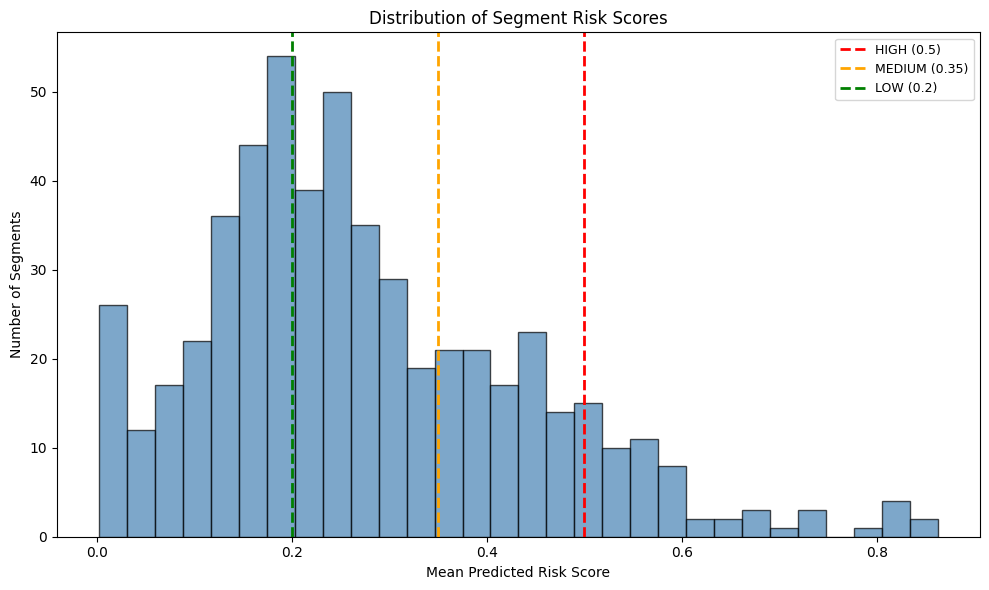

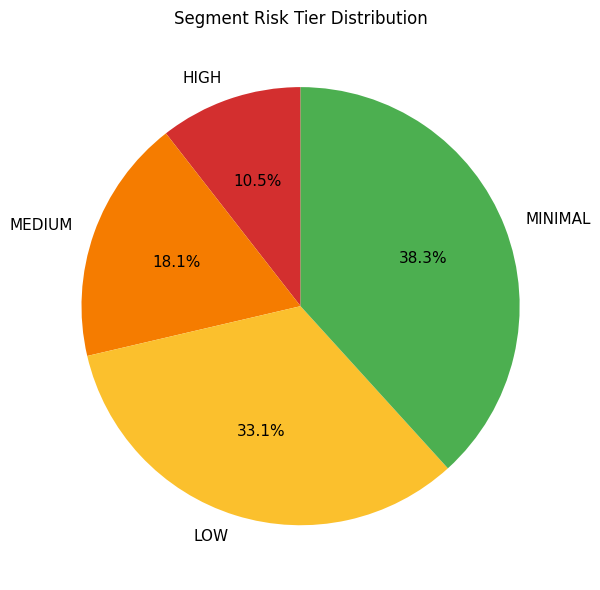

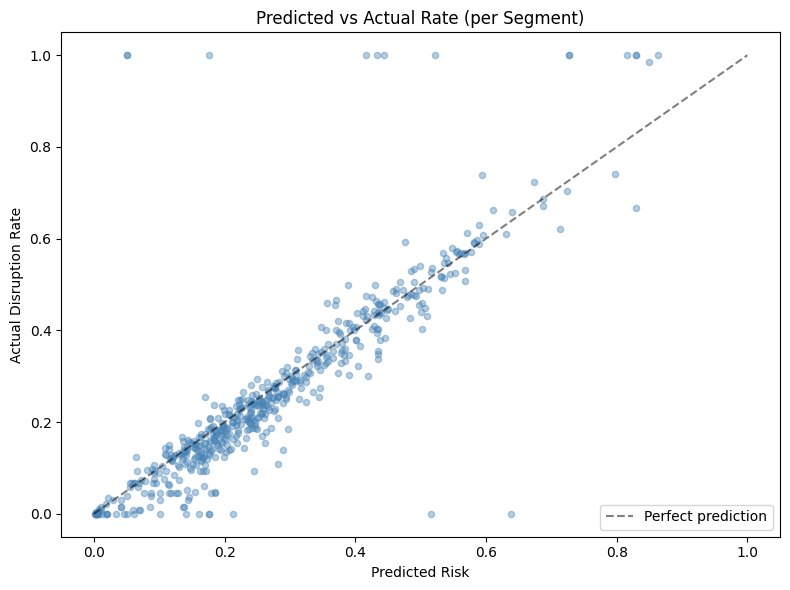

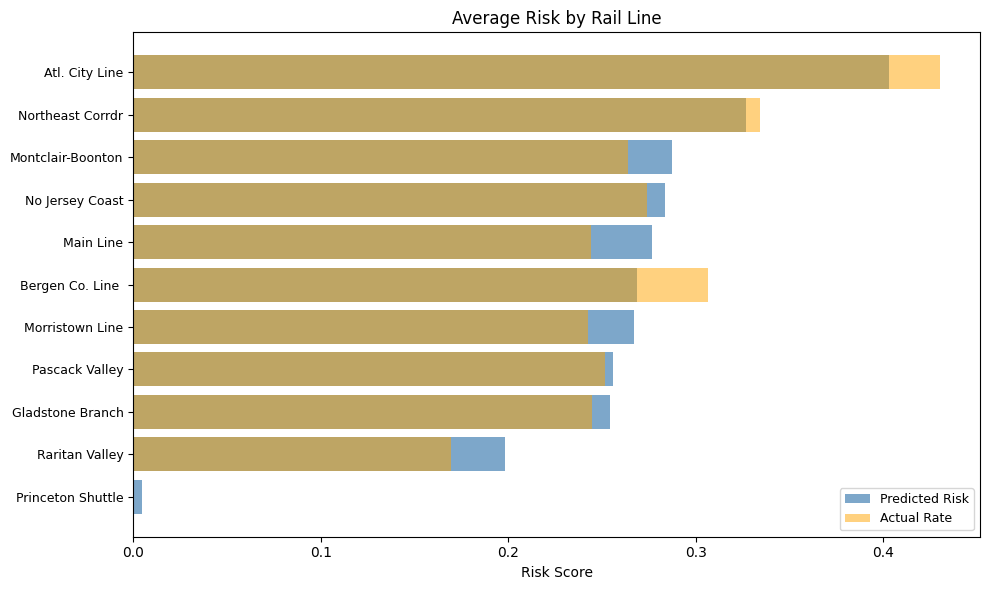

,line,pred,actual,segs
0,Princeton Shuttle,0.004606,0.000000,2
1,Raritan Valley,0.198083,0.169252,52
2,Gladstone Branch,0.254204,0.244937,43
3,Pascack Valley,0.255729,0.251542,47
4,Morristown Line,0.267271,0.242808,72
5,Bergen Co. Line,0.268561,0.306566,62
6,Main Line,0.276451,0.244034,48
7,No Jersey Coast,0.283524,0.274092,71
8,Montclair-Boonton,0.287149,0.263653,68
9,Northeast Corrdr,0.326818,0.334108,57


Saved: 4 individual risk analysis figs + table_risk_by_line.xlsx


In [27]:
# Segment risk visualisation — individual plots

# Plot 1: Risk score distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(seg_risk['mean_risk'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0.5, color='red', ls='--', lw=2, label='HIGH (0.5)')
ax.axvline(x=0.35, color='orange', ls='--', lw=2, label='MEDIUM (0.35)')
ax.axvline(x=0.2, color='green', ls='--', lw=2, label='LOW (0.2)')
ax.set_xlabel('Mean Predicted Risk Score'); ax.set_ylabel('Number of Segments')
ax.set_title('Distribution of Segment Risk Scores'); ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Risk tier pie chart
fig, ax = plt.subplots(figsize=(8, 6))
tc = seg_risk['risk_tier'].value_counts().reindex(['HIGH','MEDIUM','LOW','MINIMAL']).fillna(0)
ax.pie(tc.values, labels=tc.index, colors=['#d32f2f','#f57c00','#fbc02d','#4caf50'],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Segment Risk Tier Distribution')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_risk_tier_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 3: Predicted vs actual scatter
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(seg_risk['mean_risk'], seg_risk['actual_rate'], alpha=0.4, s=20, color='steelblue')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Predicted Risk'); ax.set_ylabel('Actual Disruption Rate')
ax.set_title('Predicted vs Actual Rate (per Segment)'); ax.legend()
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 4: Risk by rail line
fig, ax = plt.subplots(figsize=(10, 6))
line_risk = seg_risk.groupby('line').agg(pred=('mean_risk','mean'), actual=('actual_rate','mean'),
                                          segs=('segment_id','count')).sort_values('pred', ascending=True)
y_pos = range(len(line_risk))
ax.barh(y_pos, line_risk['pred'], alpha=0.7, label='Predicted Risk', color='steelblue')
ax.barh(y_pos, line_risk['actual'], alpha=0.5, label='Actual Rate', color='orange')
ax.set_yticks(y_pos); ax.set_yticklabels(line_risk.index, fontsize=9)
ax.set_xlabel('Risk Score'); ax.set_title('Average Risk by Rail Line'); ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_risk_by_line.png', dpi=150, bbox_inches='tight')
plt.show()

line_risk.reset_index().to_excel(f'{EXPORT_DIR}/table_risk_by_line.xlsx', index=False)
display(line_risk.reset_index())
print(f'Saved: 4 individual risk analysis figs + table_risk_by_line.xlsx')


## 17. Classification Reports

In [28]:
# Classification reports

with open(f'{EXPORT_DIR}/classification_reports.txt', 'w') as f:
    for name, r in all_r.items():
        hdr = f"{'='*60}\n{name}\n{'='*60}"
        rpt = classification_report(y_test, r['y_pred'], target_names=['No Disruption','Disruption'], digits=4)
        print(hdr); print(rpt)
        f.write(hdr+'\n'+rpt+'\n')
print(f'Saved: {EXPORT_DIR}/classification_reports.txt')

LR + CW
               precision    recall  f1-score   support

No Disruption     0.8289    0.7540    0.7896    486980
   Disruption     0.4235    0.5373    0.4737    163832

     accuracy                         0.6994    650812
    macro avg     0.6262    0.6456    0.6317    650812
 weighted avg     0.7268    0.6994    0.7101    650812

RF + CW
               precision    recall  f1-score   support

No Disruption     0.8108    0.8731    0.8408    486980
   Disruption     0.5112    0.3945    0.4453    163832

     accuracy                         0.7526    650812
    macro avg     0.6610    0.6338    0.6431    650812
 weighted avg     0.7354    0.7526    0.7413    650812

XGB + CW
               precision    recall  f1-score   support

No Disruption     0.8402    0.7932    0.8160    486980
   Disruption     0.4729    0.5516    0.5093    163832

     accuracy                         0.7324    650812
    macro avg     0.6566    0.6724    0.6626    650812
 weighted avg     0.7478    0.73

## 18. Correlation Matrix

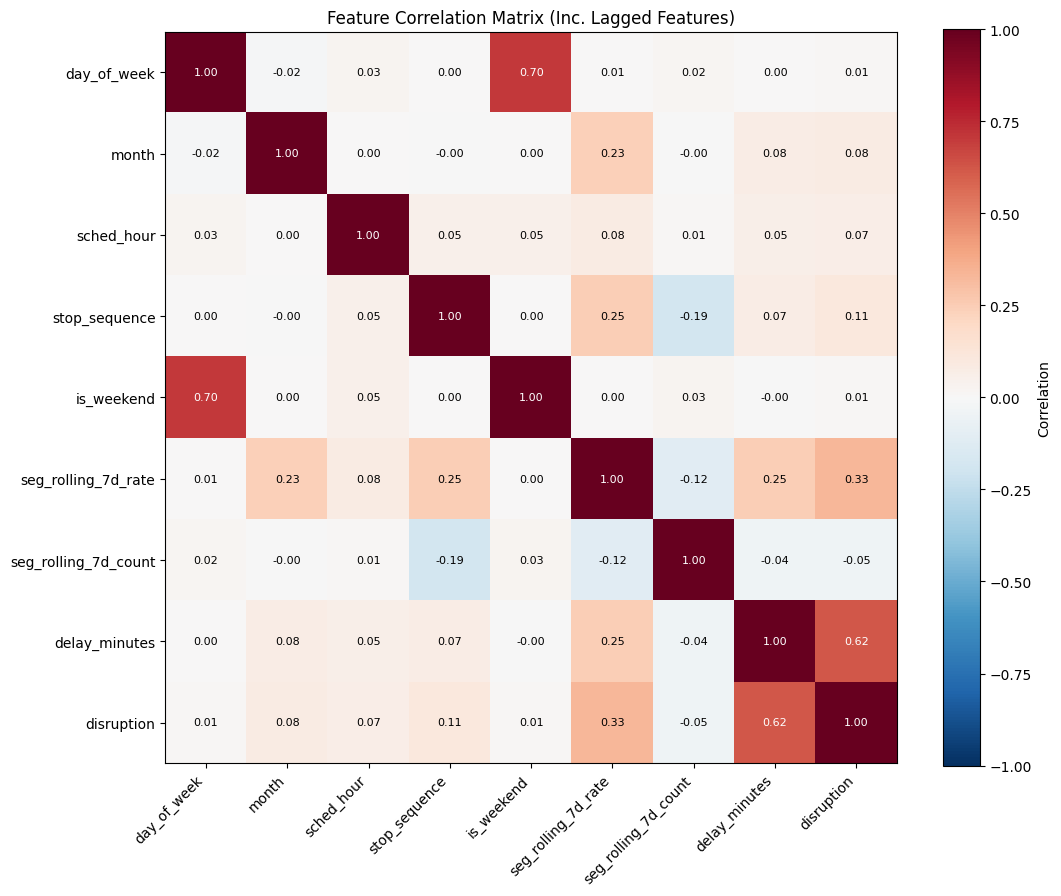

,day_of_week,month,sched_hour,stop_sequence,is_weekend,seg_rolling_7d_rate,seg_rolling_7d_count,delay_minutes,disruption
day_of_week,1.000,-0.016,0.025,0.001,0.704,0.006,0.023,0.002,0.012
month,-0.016,1.000,0.000,-0.003,0.001,0.235,-0.005,0.076,0.085
sched_hour,0.025,0.000,1.000,0.052,0.050,0.084,0.011,0.055,0.065
stop_sequence,0.001,-0.003,0.052,1.000,0.001,0.245,-0.186,0.071,0.107
is_weekend,0.704,0.001,0.050,0.001,1.000,0.001,0.026,-0.001,0.012
seg_rolling_7d_rate,0.006,0.235,0.084,0.245,0.001,1.000,-0.116,0.247,0.333
seg_rolling_7d_count,0.023,-0.005,0.011,-0.186,0.026,-0.116,1.000,-0.045,-0.046
delay_minutes,0.002,0.076,0.055,0.071,-0.001,0.247,-0.045,1.000,0.624
disruption,0.012,0.085,0.065,0.107,0.012,0.333,-0.046,0.624,1.000


Saved: fig + xlsx


In [29]:
# Correlation matrix

cc = ['day_of_week','month','sched_hour','stop_sequence','is_weekend','seg_rolling_7d_rate','seg_rolling_7d_count']
cm = df[cc + ['delay_minutes','disruption']].corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=45, ha='right')
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j,i,f'{cm.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(cm.iloc[i,j])>0.5 else 'black')
ax.set_title('Feature Correlation Matrix (Inc. Lagged Features)')
plt.tight_layout()
fig.savefig(f'{EXPORT_DIR}/fig_correlation_matrix.png', dpi=150, bbox_inches='tight')
cm.to_excel(f'{EXPORT_DIR}/table_correlation_matrix.xlsx')
plt.show()
display(cm.round(3))
print(f'Saved: fig + xlsx')

## 19. Summary

In [30]:
# Final summary


print('PROTOTYPE 3 — FINAL RESEARCH PROTOTYPE SUMMARY')

print(f'Dataset:       2018 Oct-Dec + 2019 Jan-May (8 months, cross-year)')
print(f'Records:       {len(df):,}')
print(f'Segments:      {df["segment_id"].nunique()}')
print(f'Date range:    {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Seasons:       {sorted(df["season"].unique())}')
print(f'Threshold:     >= {THRESHOLD_MIN} min')
print(f'Pos rate:      {df["disruption"].mean():.4f} ({df["disruption"].mean()*100:.1f}%)')
print(f'Split:         Train 2018 / Val 2019 Q1 / Test 2019 Q2')
print(f'Models:        7 (3 baseline + 3 SMOTE + 1 tuned)')
print(f'Best:          {best_name}')
print(f'Best PR-AUC:   {final_comp.iloc[0]["PR-AUC"]}')
print(f'Best F1:       {final_comp.iloc[0]["F1"]}')
print(f'Tuned params:  {grid_search.best_params_}')
print(f'Threshold:     {best_thresh}')
print(f'')
print(f'Improvements over Prototype 2:')
print(f'  - Cross-year generalisation (2018 -> 2019)')
print(f'  - Lagged features (seg_rolling_7d_rate/count)')
print(f'  - Hyperparameter tuning (GridSearchCV)')
print(f'  - Seasonal disruption analysis')
print(f'  - Segment-level early warning with risk tiers')
print(f'')
print('Exported files:')
for fn in sorted(os.listdir(EXPORT_DIR)):
    sz = os.path.getsize(os.path.join(EXPORT_DIR, fn))
    print(f'  {fn:<50} {sz/1024:.1f} KB')


PROTOTYPE 3 — FINAL RESEARCH PROTOTYPE SUMMARY
Dataset:       2018 Oct-Dec + 2019 Jan-May (8 months, cross-year)
Records:       1,678,487
Segments:      572
Date range:    2018-10-01 to 2019-05-31
Seasons:       ['Autumn', 'Spring', 'Winter']
Threshold:     >= 5 min
Pos rate:      0.2909 (29.1%)
Split:         Train 2018 / Val 2019 Q1 / Test 2019 Q2
Models:        7 (3 baseline + 3 SMOTE + 1 tuned)
Best:          XGB + CW (Tuned)
Best PR-AUC:   0.5134
Best F1:       0.5093
Tuned params:  {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
Threshold:     0.4

Improvements over Prototype 2:
  - Cross-year generalisation (2018 -> 2019)
  - Lagged features (seg_rolling_7d_rate/count)
  - Hyperparameter tuning (GridSearchCV)
  - Seasonal disruption analysis
  - Segment-level early warning with risk tiers

Exported files:
  classification_reports.txt                         3.2 KB
  fig_calibration_curves.png                         103.2 KB
  fig_cm_10min.png                       